# MANU 465 Group Project - Concrete Compressive Strength Predictions

Team Memebers:

Callum Abraham [84939693]

Mriduti Datta [39804257]

Max Teplitskiy [70977434]

Eric Lu [25133307]

## Imports

In [4]:
#Utilities
from pathlib import Path
import pandas as pd
import numpy as np

#Plotting 
import matplotlib.pyplot as plt
import seaborn as sns

#Model Production
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error, r2_score
import xgboost as xgb

## Data Loading

In [ ]:
#Load the dataset and look at the info of the dataset
csv_path = Path("concrete_data.xls")
dataset = pd.read_excel(csv_path)
dataset.info()

We can see that no data is missing from the file. 

## Data Visualization

In [6]:
#Investiage Sample data points in the dataset
display(dataset.sample(15,random_state=1))

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
339,297.2,0.0,117.5,174.8,9.5,1022.8,753.5,3,21.91
244,238.1,0.0,94.1,186.7,7.0,949.9,847.0,3,19.93
882,140.0,133.0,103.0,200.0,7.0,916.0,753.0,28,36.44
567,203.5,135.7,0.0,185.7,0.0,1076.2,759.3,7,11.96
923,162.0,207.0,172.0,216.0,10.0,822.0,638.0,28,39.84
358,277.2,97.8,24.5,160.7,11.2,1061.7,782.5,100,66.95
576,339.2,0.0,0.0,185.7,0.0,1069.2,754.3,7,21.18
27,342.0,38.0,0.0,228.0,0.0,932.0,670.0,180,52.12
994,374.3,0.0,0.0,190.2,6.7,1013.2,730.4,28,39.06
563,210.7,316.1,0.0,185.7,0.0,977.0,689.3,7,21.82


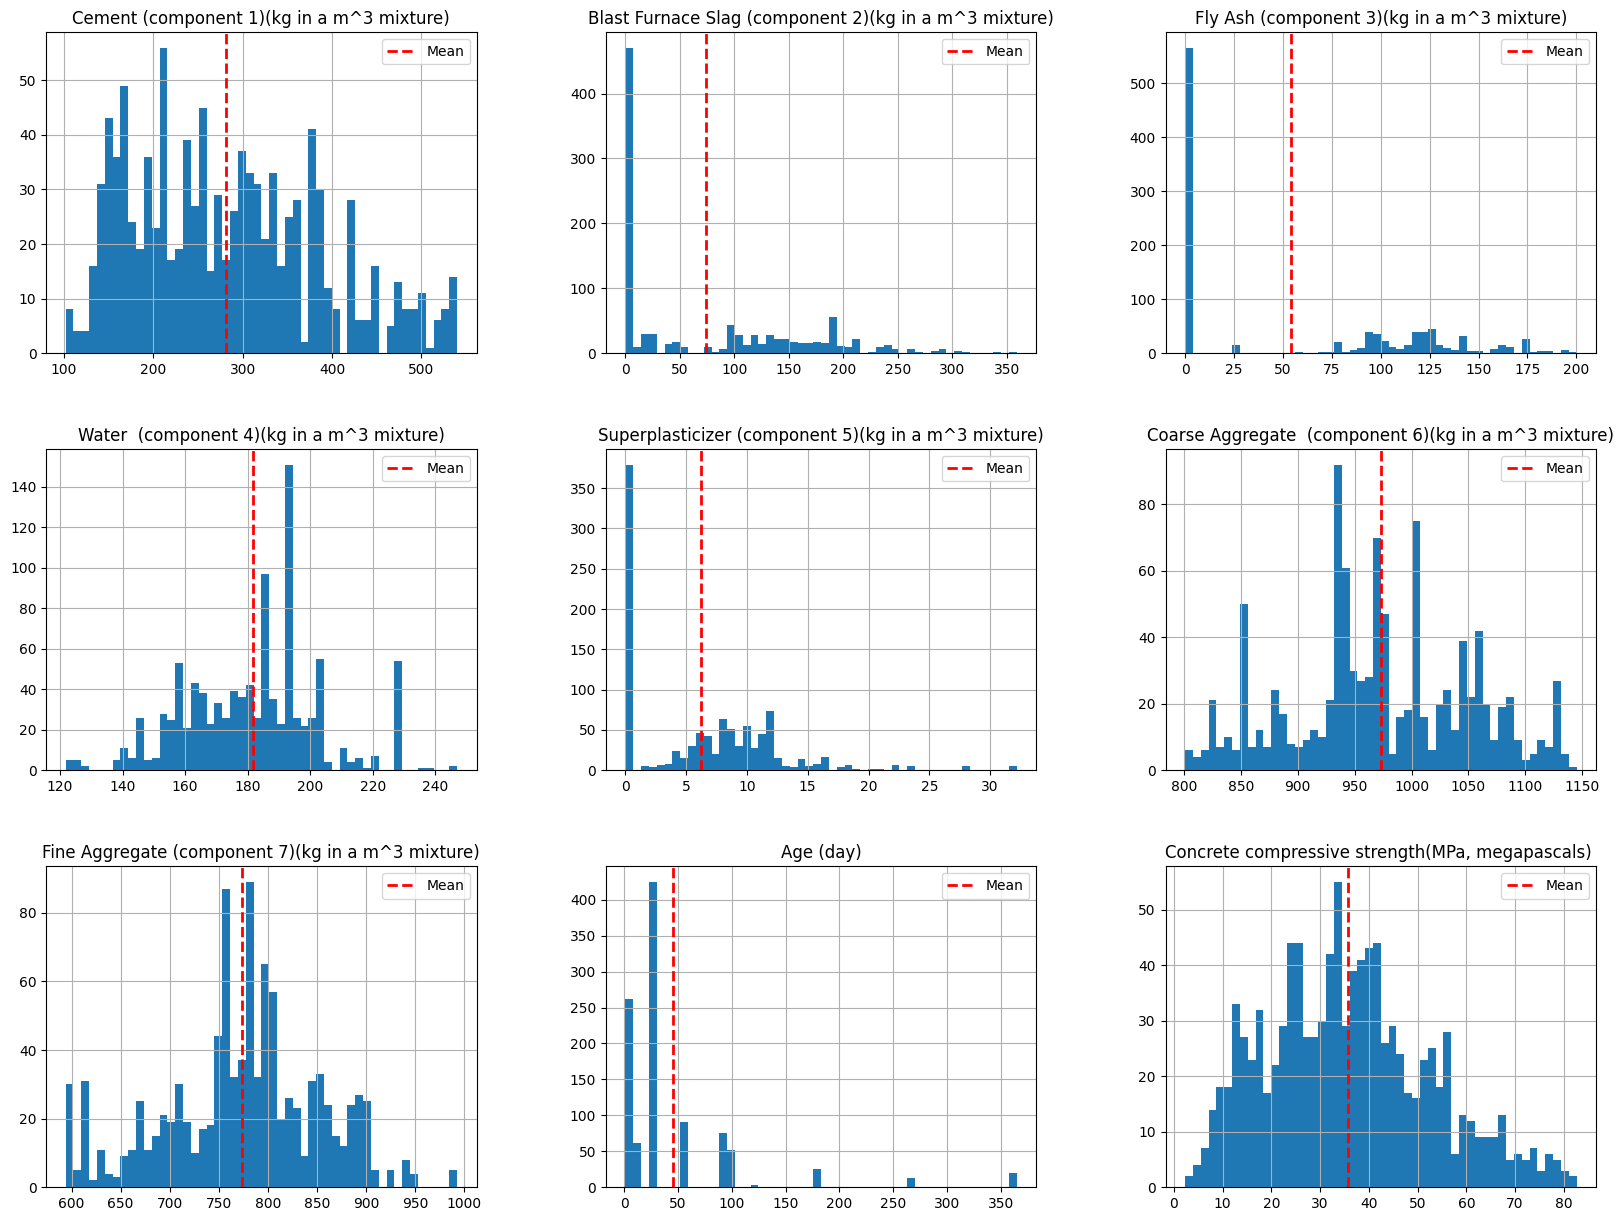

In [7]:
#Histogram of the plots of the dataset with mean shown as a vertical line
dataset.hist(bins=50, figsize=(20,15))
for i, ax in enumerate(plt.gcf().axes):
    ax.axvline(dataset.iloc[:, i].mean(), color='r', linestyle='dashed', linewidth=2, label='Mean')
    ax.legend()
plt.show()

## Train, Validation, and Test Split

We will use a standard 75/25 train test split for our data set

In [8]:
#Seperate the input (x) data T, AP, RH, and V data from the output (y) data EP 
y_data = dataset[[dataset.columns[-1]]]
x_data = dataset.iloc[:,:-1]

#Use the sklearn.model_selection train_test_split function to split the data, set random state = 1 for reproducibiltiy
x_train, x_test, y_train, y_test = train_test_split(x_data,y_data, test_size=0.25, random_state=1)

datasets_dict = {
    "X Training Data" : x_train,
    "X Test Data" : x_test,
    "Y Training Data" : y_train,
    "Y Test Data" : y_test
}

# Unscaled copy for ANN
ann_datasets_dict = datasets_dict

#Checks to see data after split:
for key, value in datasets_dict.items():
    print(f"The {key} Set Contains the Following:")
    rows = value.shape[0]
    cols = value.shape[1] if len(value.shape) > 1 else 1
    print(f"{rows} Rows and {cols} Columns")
    display(value.head())

The X Training Data Set Contains the Following:
772 Rows and 8 Columns


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
773,382.0,0.0,0.0,186.0,0.0,1047.0,739.0,28
890,158.0,0.0,195.0,220.0,11.0,898.0,713.0,28
233,213.7,98.1,24.5,181.7,6.9,1065.8,785.4,100
12,427.5,47.5,0.0,228.0,0.0,932.0,594.0,270
250,250.0,0.0,95.7,187.4,5.5,956.9,861.2,14


The X Test Data Set Contains the Following:
258 Rows and 8 Columns


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
339,297.2,0.0,117.5,174.8,9.5,1022.8,753.5,3
244,238.1,0.0,94.1,186.7,7.0,949.9,847.0,3
882,140.0,133.0,103.0,200.0,7.0,916.0,753.0,28
567,203.5,135.7,0.0,185.7,0.0,1076.2,759.3,7
923,162.0,207.0,172.0,216.0,10.0,822.0,638.0,28


The Y Training Data Set Contains the Following:
772 Rows and 1 Columns


,"Concrete compressive strength(MPa, megapascals)"
773,37.42
890,8.54
233,53.90
12,43.01
250,24.92


The Y Test Data Set Contains the Following:
258 Rows and 1 Columns


,"Concrete compressive strength(MPa, megapascals)"
339,21.91
244,19.93
882,36.44
567,11.96
923,39.84


## Apply Scaling

In [9]:
#Set the StandardScaler fucntion for easy implementation and set the output as a pandas.DataFrame
scaler_X = StandardScaler().set_output(transform='pandas')
scaler_Y = StandardScaler().set_output(transform='pandas')


#Scale the input and output data using the fit_transform fucntion
#Ensuring that test data is ONLY transformed and not fit to reduce leakage
y_scaler = None
for key, value in datasets_dict.items():
    if "Train" in key:
        if "X" in key:
            datasets_dict[key] = scaler_X.fit_transform(value)
        if "Y" in key:
            datasets_dict[key] = scaler_Y.fit_transform(value)
    if "Test" in key:
        if "X" in key:
            datasets_dict[key] = scaler_X.transform(value)
        if "Y" in key:
            datasets_dict[key] = scaler_Y.transform(value)

    print(f"The {key} Set Contains the Following:")
    print(f"{datasets_dict[key].shape[0]} Rows and {datasets_dict[key].shape[1]} Columns")
    display(datasets_dict[key].head())

The X Training Data Set Contains the Following:
772 Rows and 8 Columns


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
773,0.973894,-0.838014,-0.849289,0.217303,-1.034629,0.946951,-0.493904,-0.273743
890,-1.163906,-0.838014,2.177087,1.837689,0.854889,-0.962452,-0.825535,-0.273743
233,-0.632319,0.323740,-0.469052,0.012371,0.150614,1.187869,0.097928,0.903855
12,1.408135,-0.275493,-0.849289,2.218957,-1.034629,-0.526749,-2.343380,3.684296
250,-0.285881,-0.838014,0.635963,0.284024,-0.089870,-0.207661,1.064757,-0.502721


The X Test Data Set Contains the Following:
258 Rows and 8 Columns


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
339,0.164584,-0.838014,0.974296,-0.316472,0.597228,0.636833,-0.308957,-0.682632
244,-0.399452,-0.838014,0.611131,0.250664,0.167792,-0.297364,0.883636,-0.682632
882,-1.335694,0.737046,0.749258,0.884521,0.167792,-0.731786,-0.315334,-0.273743
567,-0.729666,0.769021,-0.849289,0.203005,-1.034629,1.321143,-0.234978,-0.617210
923,-1.125731,1.613395,1.820129,1.647055,0.683115,-1.936375,-1.782160,-0.273743


The Y Training Data Set Contains the Following:
772 Rows and 1 Columns


,"Concrete compressive strength(MPa, megapascals)"
773,0.114033
890,-1.604373
233,1.094619
12,0.446647
250,-0.629737


The Y Test Data Set Contains the Following:
258 Rows and 1 Columns


,"Concrete compressive strength(MPa, megapascals)"
339,-0.808837
244,-0.926650
882,0.055721
567,-1.400878
923,0.258027


## Model 1 Polynomial Regression

,MAE (MPa),RMSE (MPa),R2 Score,Features
Order,,,,
Degree 1,8.59,10.90,0.554670,8
Degree 2,6.08,8.02,0.758693,44
Degree 3,5.13,7.38,0.796061,164
Degree 4,25.20,96.90,-34.203234,494


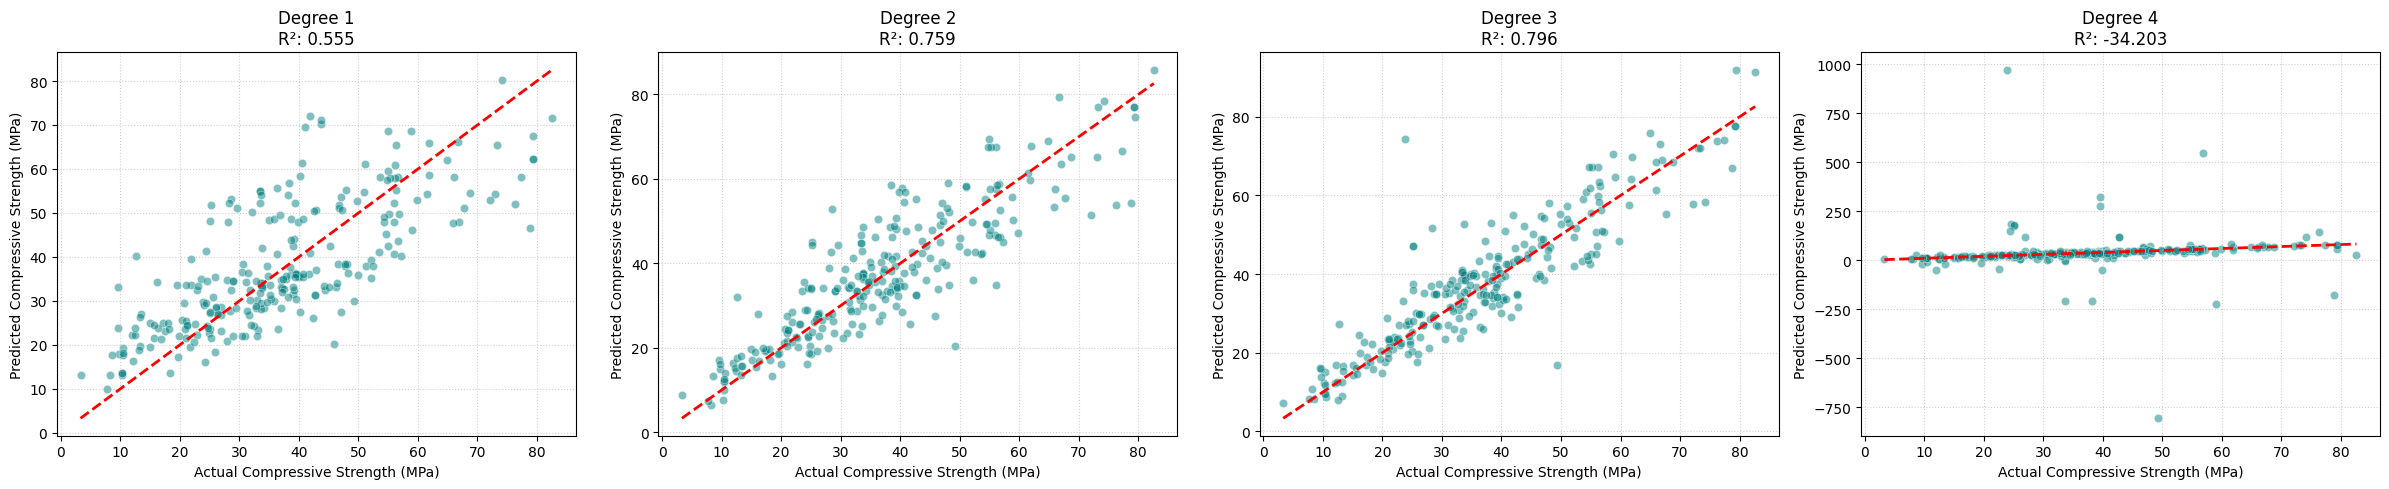

In [10]:
def full_polynomial_analysis(datasets, orders):
    X_train, X_test = datasets["X Training Data"], datasets["X Test Data"]
    y_train, y_test = datasets["Y Training Data"], datasets["Y Test Data"]
        
    stats_list = []
    fig, axes = plt.subplots(1, len(orders), figsize=(6 * len(orders), 5), sharey=False)
    
    if len(orders) == 1: 
        axes = [axes]

    for i, n in enumerate(orders):

        #Transform the data for polynomial fitting
        poly = PolynomialFeatures(degree=n, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        
        #Define and fit the model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)
        
        y_pred_mpa = scaler_Y.inverse_transform(pd.DataFrame(y_pred, columns=y_test.columns))
        y_test_mpa = scaler_Y.inverse_transform(y_test)

        y_true_1d = np.ravel(y_test_mpa)
        y_pred_1d = np.ravel(y_pred_mpa)
        mse = mean_squared_error(y_true_1d, y_pred_1d)
        mae = mean_absolute_error(y_true_1d, y_pred_1d)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true_1d, y_pred_1d)
        
        stats_list.append({
            "Order": f"Degree {n}",
            "MAE (MPa)": mae,
            "RMSE (MPa)": rmse,
            "R2 Score": r2,
            "Features": X_train_poly.shape[1]
        })
        
        sns.scatterplot(x=y_true_1d, y=y_pred_1d, ax=axes[i], alpha=0.5, color='teal')
        
        line_lims = [y_true_1d.min(), y_true_1d.max()]
        axes[i].plot(line_lims, line_lims, 'r--', lw=2)
        
        axes[i].set_title(f"Degree {n}\nR²: {r2:.3f}")
        axes[i].set_xlabel("Actual Compressive Strength (MPa)")
        axes[i].set_ylabel("Predicted Compressive Strength (MPa)")
        axes[i].grid(True, linestyle=':', alpha=0.6)

    summary_df = pd.DataFrame(stats_list).set_index("Order")
    styled_table = summary_df.style.highlight_max(subset=['R2 Score'], color="#90ee90") \
                                   .highlight_min(subset=['MAE (MPa)', 'RMSE (MPa)'], color='#90ee90') \
                                   .format("{:.2f}", subset=['MAE (MPa)', 'RMSE (MPa)'])
    
    display(styled_table)
    
    plt.tight_layout()
    plt.show()

full_polynomial_analysis(datasets_dict, [1, 2, 3, 4])

## Model 2 XGBoost

,MAE (MPa),RMSE (MPa),R2 Score
Depth,,,
Depth 3,3.85,5.31,0.894291
Depth 5,3.26,4.74,0.915908
Depth 7,3.33,5.05,0.904385
Depth 9,3.37,5.12,0.901803


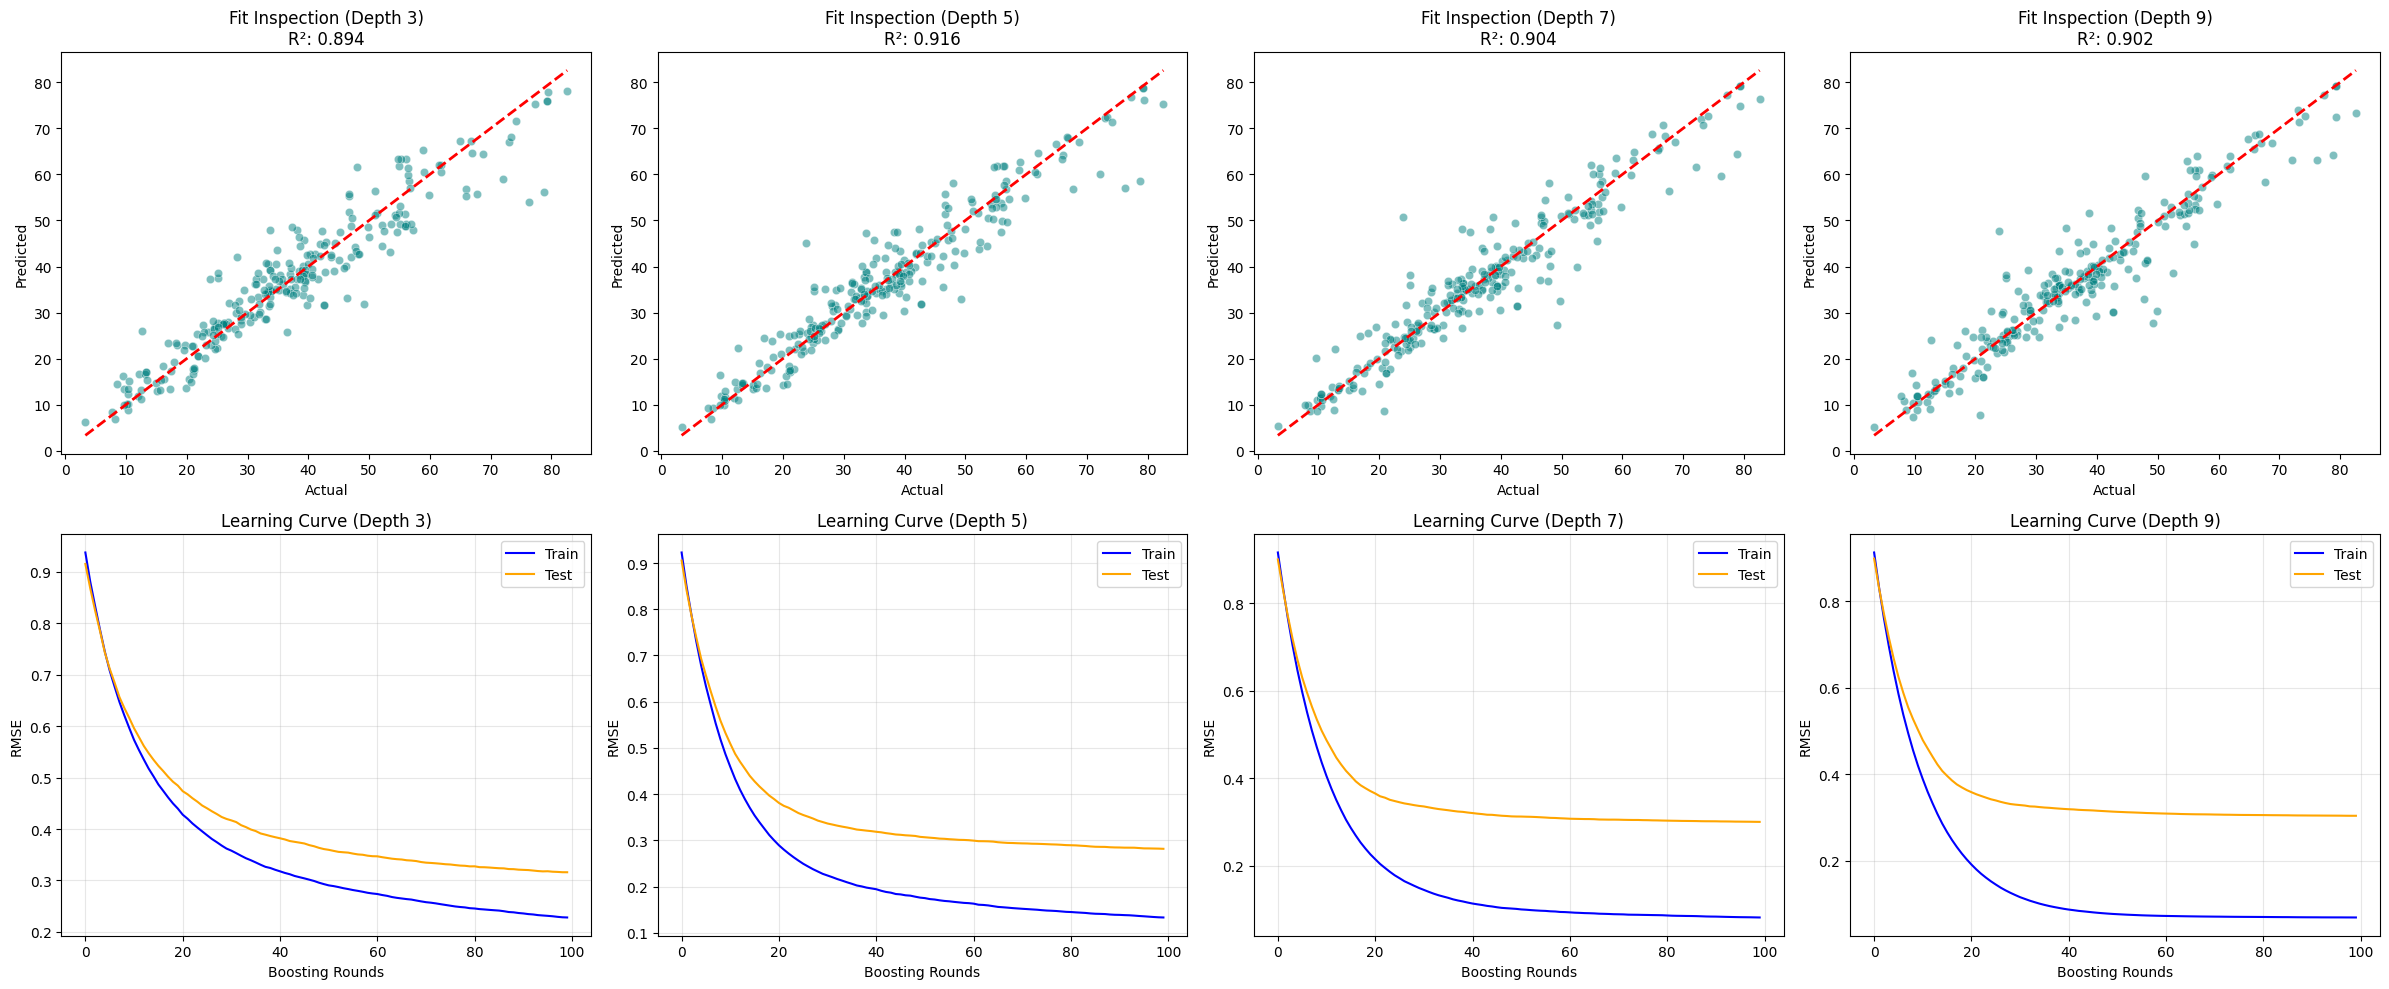

In [11]:
def xgboost_analysis(datasets, depths):
    X_train, X_test = datasets["X Training Data"], datasets["X Test Data"]
    y_train, y_test = datasets["Y Training Data"], datasets["Y Test Data"]
    
    # Use the y_scaler to inverse transform metrics back to MPa units    
    stats_list = []
    num_models = len(depths)
    
    fig, axes = plt.subplots(2, num_models, figsize=(6 * num_models, 10), sharey=False)
    
    if num_models == 1:
        axes = np.reshape(axes, (2, 1))

    for i, n in enumerate(depths):

        model = xgb.XGBRegressor(n_estimators=100, max_depth=n, learning_rate=0.1, random_state=1)
        model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
        
        results = model.evals_result()
        y_pred = model.predict(X_test)
        
        y_pred_mpa = scaler_Y.inverse_transform(pd.DataFrame(y_pred, columns=y_test.columns))
        y_test_mpa = scaler_Y.inverse_transform(y_test)

        y_true_1d = np.ravel(y_test_mpa)
        y_pred_1d = np.ravel(y_pred_mpa)
        mse = mean_squared_error(y_true_1d, y_pred_1d)
        mae = mean_absolute_error(y_true_1d, y_pred_1d)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true_1d, y_pred_1d)
        
        
        stats_list.append({
            "Depth": f"Depth {n}",
            "MAE (MPa)": mae,
            "RMSE (MPa)": rmse,
            "R2 Score": r2
        })
        
        sns.scatterplot(x=y_true_1d, y=y_pred_1d, ax=axes[0, i], alpha=0.5, color='teal')
        lims = [y_true_1d.min(), y_true_1d.max()]
        axes[0, i].plot(lims, lims, 'r--', lw=2)
        axes[0, i].set_title(f"Fit Inspection (Depth {n})\nR²: {r2:.3f}")
        axes[0, i].set_xlabel("Actual")
        axes[0, i].set_ylabel("Predicted")

        axes[1, i].plot(results['validation_0']['rmse'], label='Train', color='blue')
        axes[1, i].plot(results['validation_1']['rmse'], label='Test', color='orange')
        axes[1, i].set_title(f"Learning Curve (Depth {n})")
        axes[1, i].set_xlabel("Boosting Rounds")
        axes[1, i].set_ylabel("RMSE")
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)

    summary_df = pd.DataFrame(stats_list).set_index("Depth")
    styled_table = summary_df.style.highlight_max(subset=['R2 Score'], color="#90ee90") \
                                   .highlight_min(subset=['MAE (MPa)', 'RMSE (MPa)'], color='#90ee90') \
                                   .format("{:.2f}", subset=['MAE (MPa)', 'RMSE (MPa)'])
        
    display(styled_table)

    plt.tight_layout()
    plt.show()

xgboost_analysis(datasets_dict, [3, 5, 7, 9])

## Model 3 Artificial Neural Network

### Additional preprocessing: Augmentation

In [12]:
# Separate preprocessling pipeline with augemntation for ANN 
def preprocess(ann_datasets_dict, augment):
    X_train, X_test = ann_datasets_dict["X Training Data"], ann_datasets_dict["X Test Data"]
    y_train, y_test = ann_datasets_dict["Y Training Data"], ann_datasets_dict["Y Test Data"]

    # Scale on augmented data
    x_scaler = StandardScaler().set_output(transform='pandas')
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_test  = x_scaler.transform(X_test)
    y_train = y_scaler.fit_transform(y_train.values)
    y_test  = y_scaler.transform(y_test.values)

    if augment:
        np.random.seed(67)
        aug_factor = 20
        X_train_aug = np.tile(X_train, (aug_factor, 1)) + np.random.normal(0, 0.02, (len(X_train)*aug_factor, X_train.shape[1]))
        y_train_aug = np.tile(y_train.flatten(), aug_factor) + np.random.normal(0, 0.005, len(y_train)*aug_factor)
        print(f"Augmented training size: {len(X_train_aug)} (from {len(X_train)})")
        return X_train_aug, X_test, y_train_aug, y_test
    else:
        return X_train, X_test, y_train, y_test


### Main

In [14]:
import tensorflow as tf

def ann(datasets, augmentation):
    
    X_train, X_test, y_train, y_test = preprocess(datasets, augmentation)

    # Model Preparation
    reg = tf.keras.regularizers.l2(1e-5)
    act_func = 'elu'
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(units=8),
        tf.keras.layers.Dense(256, activation=act_func, kernel_regularizer=reg),
        tf.keras.layers.Dense(128, activation=act_func, kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(64, activation=act_func),
        tf.keras.layers.Dense(32, activation=act_func),
        tf.keras.layers.Dense(1)
    ])

    learning_rate = 0.001
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate), loss='mse', metrics=['mae'])

    early_stop = tf.keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True, monitor='val_mae')
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=15, min_lr=1e-7, monitor='val_mae')

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        batch_size=128, epochs=300, verbose=1,
        callbacks=[early_stop, reduce_lr]
    )
    model.summary()

    return history

ann_hist = ann(ann_datasets_dict, True) 

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### Training Results

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(ann_hist.history['loss'], label='Train Loss', color='blue')
ax.plot(ann_hist.history['val_loss'], label='Test Loss', color='orange')
ax.set_title('Loss Over Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()